# Distribution Sanity Checks

Batch quality audit across **all dictionaries** and **all resource stages**,
without using any gold/annotated data.

## Three layers of checks

**Layer 1 — Structural integrity (per-stage invariants).** Mechanical checks
that don't need linguistic knowledge. Row counts, null rates, schema
conformance, value-space conformance, duplicate rates.

**Layer 2 — Content distribution shape.** How does the data look? Vocabulary
sizes, token/type ratios, length distributions, character set usage, POS
distributions. Compared to reasonable expectations for Indonesian + regional
languages.

**Layer 3 — Transformation quality (stage-to-stage).** What fraction of rows
survives each pipeline step? Attrition rates tell us which stage is the
biggest quality bottleneck.

## Quality tiering

Each dictionary is assigned to a tier based on threshold-based rules:

| Tier | Criteria |
|---|---|
| **good** | Meets all thresholds — resources are probably usable as-is |
| **needs_attention** | Fails 1–2 thresholds — targeted fixes needed |
| **broken** | Fails 3+ thresholds or has catastrophic values — major rework needed |

Thresholds are defined up front in §2 so they're auditable. Report targeted
at the thesis's discussion section: "18/66 dictionaries are usable;
35/66 need targeted fixes; 13/66 are broken".

## Outputs

- `../evaluation/sanity/_per_dict_metrics.csv` — wide table, one row per dict,
  all metrics as columns (sort/filter in Excel for thesis tables)
- `../evaluation/sanity/_quality_tiers.csv` — tier assignment + which rules fired
- `../evaluation/sanity/_aggregate_stats.csv` — pipeline-wide totals
- Inline: aggregate plots + tier breakdown + drill-down for a specified dict

## 1. Imports & paths

In [12]:
import re
import ast
from pathlib import Path
from collections import Counter
from typing import Optional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from _common import parse_dict_id, load_direction_lookup, direction_for

# Source directories — read-only for this notebook
DIRS = {
    "extraction": Path("../CSV One Entry JSON With Font + Posisi Approach"),
    "prep":       Path("../Ekstraksi/4. Preprocessing - Remove Anomali Entri"),
    "billex":     Path("../Ekstraksi/9. Bilingual Lexicon"),
    "morph":      Path("../Ekstraksi/10. Morphology"),
    "parcor":     Path("../Ekstraksi/11. Parallel Corpus"),
    # Fixed versions (optional — used if present)
    "billex_fixed": Path("../Ekstraksi/9. Bilingual Lexicon - Fixed"),
    "morph_fixed":  Path("../Ekstraksi/10. Morphology - Fixed"),
    "parcor_fixed": Path("../Ekstraksi/11. Parallel Corpus - Fixed"),
}

DST_DIR = Path("../evaluation/sanity")
DST_DIR.mkdir(parents=True, exist_ok=True)

for name, d in DIRS.items():
    print(f"  {name:<14}  exists={d.exists()}  {d}")
print(f"\nWriting to: {DST_DIR.resolve()}")

  extraction      exists=True  ..\CSV One Entry JSON With Font + Posisi Approach
  prep            exists=True  ..\Ekstraksi\4. Preprocessing - Remove Anomali Entri
  billex          exists=True  ..\Ekstraksi\9. Bilingual Lexicon
  morph           exists=True  ..\Ekstraksi\10. Morphology
  parcor          exists=True  ..\Ekstraksi\11. Parallel Corpus
  billex_fixed    exists=True  ..\Ekstraksi\9. Bilingual Lexicon - Fixed
  morph_fixed     exists=True  ..\Ekstraksi\10. Morphology - Fixed
  parcor_fixed    exists=True  ..\Ekstraksi\11. Parallel Corpus - Fixed

Writing to: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKamus\evaluation\sanity


## 2. Quality thresholds

These are the rules that classify a dictionary into `good` /
`needs_attention` / `broken`. All thresholds are defined here so they're
visible and auditable. Adjust values as your understanding of the corpus
deepens.

In [13]:
THRESHOLDS = {
    # Billex rules
    "billex_min_rows":                50,      # too few entries = unusable
    "billex_max_null_rate":            0.05,   # >5% nulls = extraction problem
    "billex_max_multiword_ind_rate":   0.10,   # >10% multi-word Indonesian = noise
    "billex_max_identical_rate":       0.40,   # >40% identical src=tgt = no real translation
    "billex_max_duplicate_rate":       0.10,   # >10% duplicate rows = bug

    # Morphology rules
    "morph_min_rows":                  20,
    "morph_min_tag_coverage":          0.50,   # <50% tagged = POS extraction failing

    # Parcor rules
    "parcor_min_rows":                 100,
    "parcor_max_null_rate":            0.05,
    "parcor_max_placeholder_rate":     0.20,   # >20% sentences with '--' after processing = bad
    "parcor_max_short_rate":           0.30,   # >30% short rows = truncation problem
}


def violations(metrics: dict) -> list[str]:
    """Return list of threshold rule names this dictionary violates."""
    v = []

    # Billex
    if metrics.get("billex_rows", 0) < THRESHOLDS["billex_min_rows"]:
        v.append("billex_too_few_rows")
    if metrics.get("billex_null_rate", 0) > THRESHOLDS["billex_max_null_rate"]:
        v.append("billex_high_null_rate")
    if metrics.get("billex_multiword_ind_rate", 0) > THRESHOLDS["billex_max_multiword_ind_rate"]:
        v.append("billex_high_multiword_ind")
    if metrics.get("billex_identical_rate", 0) > THRESHOLDS["billex_max_identical_rate"]:
        v.append("billex_high_identical")
    if metrics.get("billex_duplicate_rate", 0) > THRESHOLDS["billex_max_duplicate_rate"]:
        v.append("billex_high_duplicates")

    # Morphology
    if metrics.get("morph_rows", 0) < THRESHOLDS["morph_min_rows"]:
        v.append("morph_too_few_rows")
    if metrics.get("morph_tag_coverage", 1.0) < THRESHOLDS["morph_min_tag_coverage"]:
        v.append("morph_low_tag_coverage")

    # Parcor
    if metrics.get("parcor_rows", 0) < THRESHOLDS["parcor_min_rows"]:
        v.append("parcor_too_few_rows")
    if metrics.get("parcor_null_rate", 0) > THRESHOLDS["parcor_max_null_rate"]:
        v.append("parcor_high_null_rate")
    if metrics.get("parcor_placeholder_rate", 0) > THRESHOLDS["parcor_max_placeholder_rate"]:
        v.append("parcor_high_placeholders")
    if metrics.get("parcor_short_rate", 0) > THRESHOLDS["parcor_max_short_rate"]:
        v.append("parcor_high_short_rows")

    return v


def assign_tier(violations_list: list[str]) -> str:
    n = len(violations_list)
    if n == 0:
        return "good"
    if n <= 2:
        return "needs_attention"
    return "broken"

## 3. Per-resource metric collectors

Layer 1 (structural) and Layer 2 (distribution) combined, per resource.
Each collector reads a single CSV and returns a flat dict of metrics.

In [14]:
def parse_list_cell(s):
    if isinstance(s, list):
        return s
    try:
        v = ast.literal_eval(s) if isinstance(s, str) else []
        return v if isinstance(v, list) else []
    except Exception:
        return []


def collect_billex_metrics(path: Path, direction: Optional[int]) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0 or "kata_asal" not in df.columns or "kata_tujuan" not in df.columns:
        return {"billex_rows": n}

    # Which side is Indonesian?
    if direction == 1:
        ind_col, reg_col = "kata_asal", "kata_tujuan"
    else:
        ind_col, reg_col = "kata_tujuan", "kata_asal"

    # First translation of the list-form column — always returns a string
    def first_of(v):
        if not isinstance(v, str):
            return ""
        lst = parse_list_cell(v)
        if lst:
            first = lst[0]
            return str(first).strip() if first is not None else ""
        return v.strip()

    # Both sides normalised to strings via .fillna("") + .astype(str)
    if direction == 1:
        ind_series = df[ind_col].fillna("").astype(str).str.strip()
        reg_series = df[reg_col].apply(first_of)
    else:
        ind_series = df[ind_col].apply(first_of)
        reg_series = df[reg_col].fillna("").astype(str).str.strip()

    # Basic counts
    null_rate = df[[ind_col, reg_col]].isna().any(axis=1).mean()
    empty_ind = (ind_series == "").mean()
    empty_reg = (reg_series == "").mean()

    # Shape — str.contains with na=False is safe, but our series is already all-str
    multiword_ind_rate = ind_series.str.contains(r"\s", na=False, regex=True).mean()
    multiword_reg_rate = reg_series.str.contains(r"\s", na=False, regex=True).mean()
    identical_rate = (
        (ind_series.str.lower() == reg_series.str.lower()) & (ind_series != "")
    ).mean()
    duplicate_rate = df.duplicated(subset=[ind_col, reg_col]).mean()

    # Vocabulary — defend against any non-string values that might sneak through
    tokens_ind = Counter()
    tokens_reg = Counter()
    for v in ind_series:
        if isinstance(v, str) and v:
            tokens_ind.update(re.findall(r"[A-Za-zÀ-ÿ']+", v.lower()))
    for v in reg_series:
        if isinstance(v, str) and v:
            tokens_reg.update(re.findall(r"[A-Za-zÀ-ÿ']+", v.lower()))

    # Character set — suspicious chars
    suspicious_char_rate = (
        ind_series.str.contains(r"[0-9À-ÿ]", na=False, regex=True).sum()
        + reg_series.str.contains(r"[0-9À-ÿ]", na=False, regex=True).sum()
    ) / max(1, 2 * n)

    # Length stats
    ind_lens = ind_series.str.len()
    reg_lens = reg_series.str.len()

    return {
        "billex_rows": n,
        "billex_null_rate": round(float(null_rate), 4),
        "billex_empty_ind_rate": round(float(empty_ind), 4),
        "billex_empty_reg_rate": round(float(empty_reg), 4),
        "billex_multiword_ind_rate": round(float(multiword_ind_rate), 4),
        "billex_multiword_reg_rate": round(float(multiword_reg_rate), 4),
        "billex_identical_rate": round(float(identical_rate), 4),
        "billex_duplicate_rate": round(float(duplicate_rate), 4),
        "billex_vocab_size_ind": len(tokens_ind),
        "billex_vocab_size_reg": len(tokens_reg),
        "billex_total_tokens_ind": sum(tokens_ind.values()),
        "billex_total_tokens_reg": sum(tokens_reg.values()),
        "billex_ttr_ind": round(len(tokens_ind) / max(1, sum(tokens_ind.values())), 4),
        "billex_ttr_reg": round(len(tokens_reg) / max(1, sum(tokens_reg.values())), 4),
        "billex_suspicious_char_rate": round(float(suspicious_char_rate), 4),
        "billex_mean_len_ind": round(float(ind_lens.mean()), 2),
        "billex_mean_len_reg": round(float(reg_lens.mean()), 2),
    }

def collect_morph_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"morph_rows": 0}

    # Tag coverage — fillna BEFORE astype to avoid "nan" strings
    if "tag" in df.columns:
        tag_col = df["tag"].fillna("").astype(str).str.strip()
        tag_coverage = (tag_col != "") & (tag_col.str.lower() != "nan")
        tag_coverage_rate = tag_coverage.mean()
        tag_dist = tag_col[tag_coverage].value_counts(normalize=True).to_dict()
    else:
        tag_coverage_rate = 0.0
        tag_dist = {}

    # Form column
    POS_TAGS = ["adv", "pron", "num", "vt", "vi", "v", "a", "n", "p"]
    POS_ALT = "|".join(POS_TAGS)
    POS_RE = re.compile(rf"(?:^|\s)({POS_ALT})(?:\s|$)")

    if "form" in df.columns:
        form_col = df["form"].fillna("").astype(str)
        inline_pos_rate = form_col.str.contains(POS_RE, na=False, regex=True).mean()
        # Compute token count per row WITHOUT chaining .str.len() on split results
        # (that chain fails when any row produces NaN during pandas dtype inference)
        token_counts = form_col.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
        mean_form_tokens = token_counts.mean()
    else:
        inline_pos_rate = 0.0
        mean_form_tokens = 0.0

    # Duplicates
    if "kata" in df.columns and "form" in df.columns:
        dup_rate = df.duplicated(subset=["kata", "form"]).mean()
    else:
        dup_rate = 0.0

    metrics = {
        "morph_rows": n,
        "morph_tag_coverage": round(float(tag_coverage_rate), 4),
        "morph_inline_pos_rate": round(float(inline_pos_rate), 4),
        "morph_mean_form_tokens": round(float(mean_form_tokens), 2),
        "morph_duplicate_rate": round(float(dup_rate), 4),
    }
    for tag in ["n", "v", "vt", "vi", "a", "adv"]:
        metrics[f"morph_tag_pct_{tag}"] = round(tag_dist.get(tag, 0.0), 4)

    return metrics

def collect_parcor_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"parcor_rows": 0}

    if "kalimat_asal" not in df.columns or "kalimat_tujuan" not in df.columns:
        return {"parcor_rows": n, "parcor_null_rate": 1.0}

    # fillna BEFORE astype
    asal = df["kalimat_asal"].fillna("").astype(str)
    tujuan = df["kalimat_tujuan"].fillna("").astype(str)

    null_rate = df[["kalimat_asal", "kalimat_tujuan"]].isna().any(axis=1).mean()

    # Unresolved placeholders
    placeholder_re = re.compile(r"(?:^|\s)(--|-)(?=\s|$|[.,;:!?])")
    ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()

    # Length — use apply instead of chained str accessors
    len_asal = asal.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    len_tujuan = tujuan.apply(lambda s: len(s.split()) if isinstance(s, str) else 0)
    short_rate = ((len_asal <= 2) | (len_tujuan <= 2)).mean()

    # Length ratio
    with np.errstate(divide="ignore", invalid="ignore"):
        ratios = len_tujuan / len_asal.replace(0, np.nan)
    imbalanced_rate = ((ratios < 0.4) | (ratios > 2.5)).fillna(True).mean()

    # Duplicates
    dup_rate = df.duplicated(subset=["kalimat_asal", "kalimat_tujuan"]).mean()

    return {
        "parcor_rows": n,
        "parcor_null_rate": round(float(null_rate), 4),
        "parcor_placeholder_rate": round(float(ph_rate), 4),
        "parcor_short_rate": round(float(short_rate), 4),
        "parcor_imbalanced_rate": round(float(imbalanced_rate), 4),
        "parcor_duplicate_rate": round(float(dup_rate), 4),
        "parcor_mean_len_asal": round(float(len_asal.mean()), 2),
        "parcor_mean_len_tujuan": round(float(len_tujuan.mean()), 2),
    }

def collect_prep_metrics(path: Path) -> dict:
    df = pd.read_csv(path)
    n = len(df)
    if n == 0:
        return {"prep_rows": 0}

    metrics = {"prep_rows": n}
    if "is_anomali" in df.columns:
        metrics["prep_anomali_rate"] = round(float(df["is_anomali"].mean()), 4)
    if "main_entry" in df.columns:
        metrics["prep_main_entry_rate"] = round(float(df["main_entry"].mean()), 4)
    return metrics

## 4. Batch: iterate every dictionary

Loop through all Billex files (Billex is our "canonical" resource list
— a dictionary exists in the pipeline if it has a Billex file).
For each dict, collect metrics from every resource it has.

In [15]:
direction_lookup = load_direction_lookup()

billex_files = sorted(DIRS["billex"].glob("*_Billex.csv")) if DIRS["billex"].exists() else []
dict_ids = [parse_dict_id(p.name) for p in billex_files]
dict_ids = [d for d in dict_ids if d is not None]
print(f"Found {len(dict_ids)} dictionaries to audit")


def find_csv(dir_: Path, dict_id: str, suffix: str) -> Optional[Path]:
    if not dir_.exists():
        return None
    candidates = list(dir_.glob(f"{dict_id}_{suffix}.csv"))
    return candidates[0] if candidates else None


all_metrics = []
for dict_id in dict_ids:
    metrics = {
        "dict_id": dict_id,
        "direction": direction_for(dict_id, direction_lookup),
    }
    metrics["direction_known"] = metrics["direction"] is not None

    # Prep
    prep_candidates = list(DIRS["prep"].glob(f"{dict_id}_*.csv")) if DIRS["prep"].exists() else []
    if prep_candidates:
        metrics.update(collect_prep_metrics(prep_candidates[0]))

    # Billex (original)
    billex_path = find_csv(DIRS["billex"], dict_id, "Billex")
    if billex_path:
        metrics.update(collect_billex_metrics(billex_path, metrics["direction"] or 1))

    # Morphology (original)
    morph_path = find_csv(DIRS["morph"], dict_id, "Morphology")
    if morph_path:
        metrics.update(collect_morph_metrics(morph_path))

    # Parcor (original)
    parcor_path = find_csv(DIRS["parcor"], dict_id, "Parcor")
    if parcor_path:
        metrics.update(collect_parcor_metrics(parcor_path))

    # Morphology fixed (if exists)
    morph_fixed_path = find_csv(DIRS["morph_fixed"], dict_id, "Morphology")
    if morph_fixed_path:
        m_fixed = collect_morph_metrics(morph_fixed_path)
        for k, v in m_fixed.items():
            metrics[k.replace("morph_", "morph_fixed_")] = v

    # Parcor fixed
    parcor_fixed_path = find_csv(DIRS["parcor_fixed"], dict_id, "Parcor")
    if parcor_fixed_path:
        p_fixed = collect_parcor_metrics(parcor_fixed_path)
        for k, v in p_fixed.items():
            metrics[k.replace("parcor_", "parcor_fixed_")] = v

    # Compute violations and tier TWICE — pre-fix and post-fix
    v_pre = violations(metrics)
    metrics["violations_prefix"] = ";".join(v_pre)
    metrics["violation_count_prefix"] = len(v_pre)
    metrics["tier_prefix"] = assign_tier(v_pre)

    # For post-fix: build a metrics dict that prefers _fixed values when available
    metrics_post = dict(metrics)
    for key in list(metrics):
        fixed_key = key.replace("morph_", "morph_fixed_").replace("parcor_", "parcor_fixed_")
        # Substitute when a _fixed version exists
        if fixed_key in metrics and fixed_key != key:
            metrics_post[key] = metrics[fixed_key]

    v_post = violations(metrics_post)
    metrics["violations_postfix"] = ";".join(v_post)
    metrics["violation_count_postfix"] = len(v_post)
    metrics["tier_postfix"] = assign_tier(v_post)

    # Drop the old single-tier columns if they exist
    metrics.pop("violations", None)
    metrics.pop("violation_count", None)
    metrics.pop("tier", None)

    all_metrics.append(metrics) 
    
metrics_df = pd.DataFrame(all_metrics).sort_values(
    "dict_id", key=lambda s: s.astype(int)
)
metrics_df.to_csv(DST_DIR / "_per_dict_metrics.csv", index=False)
print(f"Wrote metrics for {len(metrics_df)} dictionaries")
print(f"Columns: {len(metrics_df.columns)}")
metrics_df.head()

Found 68 dictionaries to audit


C:\Users\Legion\AppData\Local\Temp\ipykernel_3536\211902361.py:117: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  inline_pos_rate = form_col.str.contains(POS_RE, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_3536\211902361.py:161: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ph_rate = asal.str.contains(placeholder_re, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_3536\211902361.py:117: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  inline_pos_rate = form_col.str.contains(POS_RE, na=False, regex=True).mean()
C:\Users\Legion\AppData\Local\Temp\ipykernel_3536\211902361.py:161: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actua

Wrote metrics for 68 dictionaries
Columns: 66


,dict_id,direction,direction_known,prep_rows,prep_anomali_rate,billex_rows,billex_null_rate,billex_empty_ind_rate,billex_empty_reg_rate,billex_multiword_ind_rate,...,parcor_fixed_imbalanced_rate,parcor_fixed_duplicate_rate,parcor_fixed_mean_len_asal,parcor_fixed_mean_len_tujuan,violations_prefix,violation_count_prefix,tier_prefix,violations_postfix,violation_count_postfix,tier_postfix
10,1,0,True,4024,0.9853,16,0.0,0.0,0.0000,0.6875,...,0.0707,0.0000,7.54,8.29,billex_too_few_rows;billex_high_multiword_ind;...,5,broken,billex_too_few_rows;billex_high_multiword_ind;...,5,broken
21,2,0,True,4752,0.9781,76,0.0,0.0,0.0132,0.4342,...,0.1514,0.0103,9.35,9.90,billex_high_multiword_ind;morph_too_few_rows;m...,6,broken,billex_high_multiword_ind;morph_too_few_rows;m...,5,broken
30,3,0,True,834,0.9652,19,0.0,0.0,0.0526,0.8947,...,0.0960,0.0000,294.03,294.41,billex_too_few_rows;billex_high_multiword_ind;...,5,broken,billex_too_few_rows;billex_high_multiword_ind;...,3,broken
38,4,1,True,3213,0.2770,1894,0.0,0.0,0.0000,0.1193,...,0.0312,0.0000,6.32,6.92,billex_high_multiword_ind;parcor_high_placehol...,2,needs_attention,billex_high_multiword_ind,1,needs_attention
47,5,1,True,3854,0.1759,2395,0.0,0.0,0.0013,0.1846,...,0.0387,0.0029,2.56,3.02,billex_high_multiword_ind;parcor_high_short_rows,2,needs_attention,billex_high_multiword_ind;parcor_high_short_rows,2,needs_attention


## 5. Aggregate tier breakdown

The main interpretable result: how many dictionaries are usable, need work,
or are broken? Plus the top violation types so you know *what* to fix.

In [16]:
# Tier breakdown — side by side
print("=== Tier breakdown comparison ===")
pre = metrics_df["tier_prefix"].value_counts().reindex(
    ["good", "needs_attention", "broken"], fill_value=0
)
post = metrics_df["tier_postfix"].value_counts().reindex(
    ["good", "needs_attention", "broken"], fill_value=0
)
comparison = pd.DataFrame({
    "pre_fix": pre,
    "post_fix": post,
    "delta": post - pre,
})
print(comparison)

# Tier transition matrix — which dictionaries moved between tiers?
print("\n=== Tier transitions (rows = pre-fix, cols = post-fix) ===")
transitions = pd.crosstab(
    metrics_df["tier_prefix"],
    metrics_df["tier_postfix"],
    margins=True,
).reindex(
    index=["good", "needs_attention", "broken", "All"],
    columns=["good", "needs_attention", "broken", "All"],
    fill_value=0,
)
print(transitions)

# Violation rankings — both pre and post
print("\n=== Top violations (pre-fix) ===")
pre_viols = []
for v in metrics_df["violations_prefix"]:
    if isinstance(v, str) and v:
        pre_viols.extend(v.split(";"))
for rule, count in Counter(pre_viols).most_common():
    pct = count / len(metrics_df)
    print(f"  {rule:<35} {count:>3}  ({pct:.1%})")

print("\n=== Top violations (post-fix) ===")
post_viols = []
for v in metrics_df["violations_postfix"]:
    if isinstance(v, str) and v:
        post_viols.extend(v.split(";"))
for rule, count in Counter(post_viols).most_common():
    pct = count / len(metrics_df)
    print(f"  {rule:<35} {count:>3}  ({pct:.1%})")

# Per-dict tier export — now includes both
tier_df = metrics_df[[
    "dict_id",
    "tier_prefix", "violation_count_prefix", "violations_prefix",
    "tier_postfix", "violation_count_postfix", "violations_postfix",
]].copy()
tier_df.to_csv(DST_DIR / "_quality_tiers.csv", index=False)
print(f"\nWrote tier comparison to: {DST_DIR / '_quality_tiers.csv'}")

=== Tier breakdown comparison ===
                 pre_fix  post_fix  delta
good                   2         4      2
needs_attention       18        31     13
broken                48        33    -15

=== Tier transitions (rows = pre-fix, cols = post-fix) ===
tier_postfix     good  needs_attention  broken  All
tier_prefix                                        
good                2                0       0    2
needs_attention     2               16       0   18
broken              0               15      33   48
All                 4               31      33   68

=== Top violations (pre-fix) ===
  billex_high_multiword_ind            58  (85.3%)
  parcor_high_placeholders             55  (80.9%)
  morph_low_tag_coverage               32  (47.1%)
  parcor_high_short_rows               30  (44.1%)
  morph_too_few_rows                   25  (36.8%)
  billex_too_few_rows                  22  (32.4%)
  parcor_high_null_rate                17  (25.0%)
  parcor_too_few_rows              

## 6. Tier visualisation

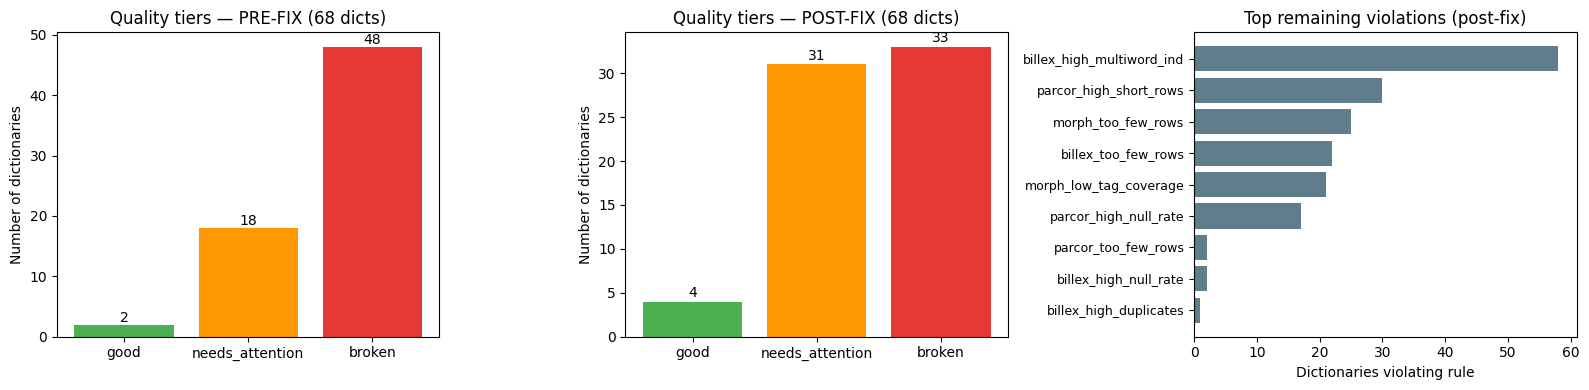

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

tier_colors = {"good": "#4caf50", "needs_attention": "#ff9800", "broken": "#e53935"}
tier_order = ["good", "needs_attention", "broken"]

# Left: pre-fix tier breakdown
pre_counts = metrics_df["tier_prefix"].value_counts().reindex(tier_order, fill_value=0)
axes[0].bar(pre_counts.index, pre_counts.values,
            color=[tier_colors[t] for t in pre_counts.index])
for i, v in enumerate(pre_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontsize=10)
axes[0].set_title(f"Quality tiers — PRE-FIX ({len(metrics_df)} dicts)")
axes[0].set_ylabel("Number of dictionaries")

# Middle: post-fix tier breakdown
post_counts = metrics_df["tier_postfix"].value_counts().reindex(tier_order, fill_value=0)
axes[1].bar(post_counts.index, post_counts.values,
            color=[tier_colors[t] for t in post_counts.index])
for i, v in enumerate(post_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontsize=10)
axes[1].set_title(f"Quality tiers — POST-FIX ({len(metrics_df)} dicts)")
axes[1].set_ylabel("Number of dictionaries")

# Right: top violations (post-fix — these are the ones still remaining after fixes)
post_viols = []
for v in metrics_df["violations_postfix"]:
    if isinstance(v, str) and v:
        post_viols.extend(v.split(";"))
violation_counts_post = Counter(post_viols)

top_v = violation_counts_post.most_common(10)
if top_v:
    labels, counts = zip(*top_v)
    axes[2].barh(range(len(labels)), counts, color="#607d8b")
    axes[2].set_yticks(range(len(labels)))
    axes[2].set_yticklabels(labels, fontsize=9)
    axes[2].invert_yaxis()
    axes[2].set_title("Top remaining violations (post-fix)")
    axes[2].set_xlabel("Dictionaries violating rule")
else:
    axes[2].text(0.5, 0.5, "No violations remain!", ha="center", va="center",
                 transform=axes[2].transAxes, fontsize=12)
    axes[2].set_title("Top remaining violations (post-fix)")

plt.tight_layout()
plt.savefig(DST_DIR / "tier_breakdown.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Distribution plots — key metrics across all dicts

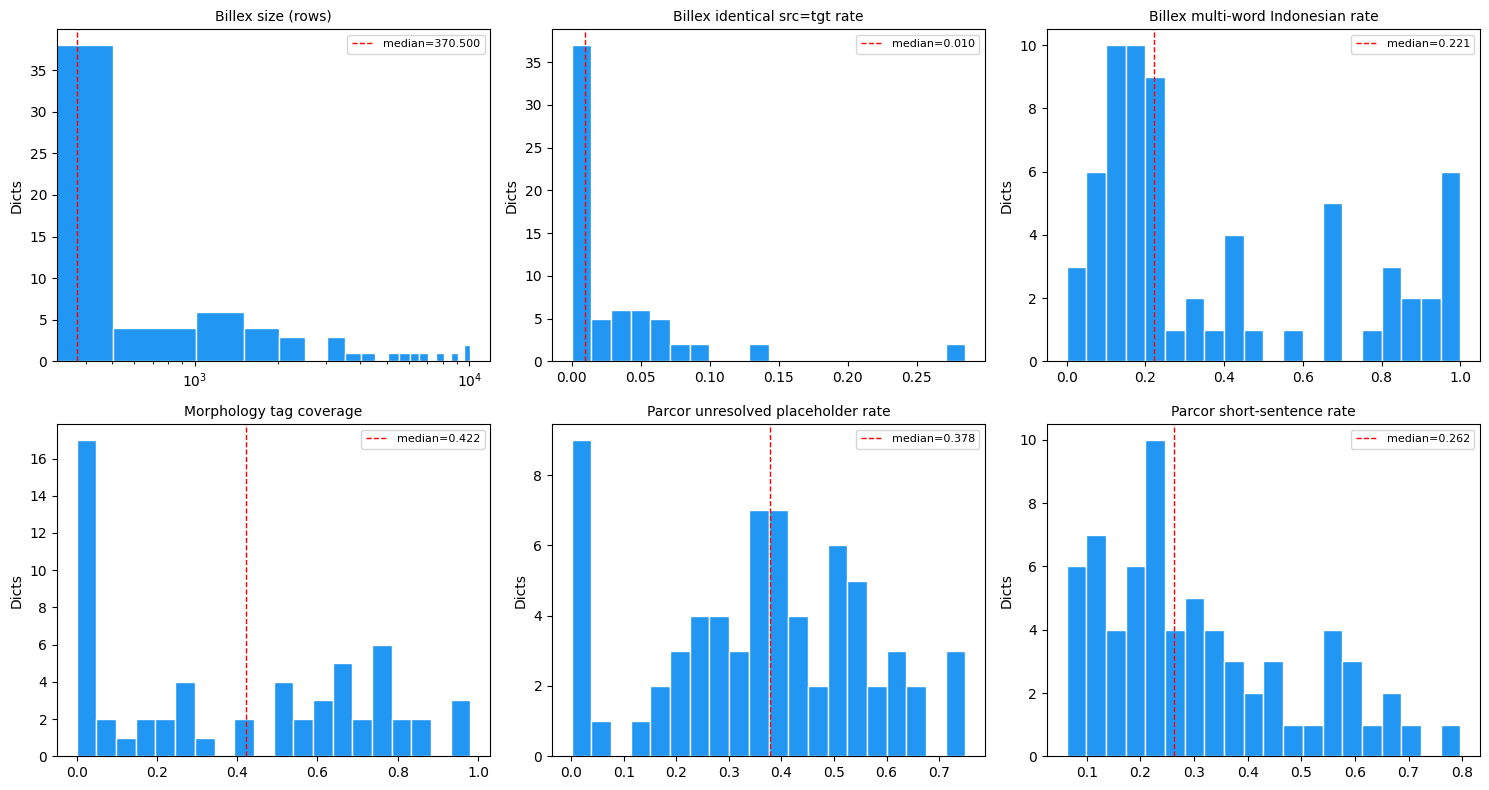

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

plot_specs = [
    ("billex_rows",              "Billex size (rows)", True),
    ("billex_identical_rate",    "Billex identical src=tgt rate", False),
    ("billex_multiword_ind_rate", "Billex multi-word Indonesian rate", False),
    ("morph_tag_coverage",       "Morphology tag coverage", False),
    ("parcor_placeholder_rate",  "Parcor unresolved placeholder rate", False),
    ("parcor_short_rate",        "Parcor short-sentence rate", False),
]

for ax, (metric, title, logx) in zip(axes.flat, plot_specs):
    if metric not in metrics_df.columns:
        ax.set_title(f"{title}\n(not available)")
        ax.axis("off")
        continue
    vals = metrics_df[metric].dropna()
    if len(vals) == 0:
        ax.set_title(f"{title}\n(empty)")
        ax.axis("off")
        continue
    ax.hist(vals, bins=20, color="#2196f3", edgecolor="white")
    if logx:
        ax.set_xscale("log")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Dicts")
    ax.axvline(vals.median(), color="red", linestyle="--", linewidth=1,
               label=f"median={vals.median():.3f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(DST_DIR / "distribution_plots.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Stage-to-stage attrition (Layer 3)

Track row counts across pipeline stages. Large attrition at a specific
stage indicates that stage is dropping a lot of data.

=== Stage-to-stage row counts (sample of 10 dicts) ===
dict_id  prep_rows  billex_rows  morph_rows  parcor_rows  billex_retention  morph_retention  parcor_retention
      1       4024           16           6         2914             0.004            0.001             0.724
      2       4752           76          12         2047             0.016            0.003             0.431
      3        834           19           1          125             0.023            0.001             0.150
      4       3213         1894         728         2658             0.589            0.227             0.827
      5       3854         2395         820          697             0.621            0.213             0.181
      8       2282          342         124          413             0.150            0.054             0.181
      9       2248           23           8         1049             0.010            0.004             0.467
     10       5287         3800        1125         2942         

C:\Users\Legion\AppData\Local\Temp\ipykernel_3536\4020147573.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[c.replace("_retention", "") for c in retention_cols])


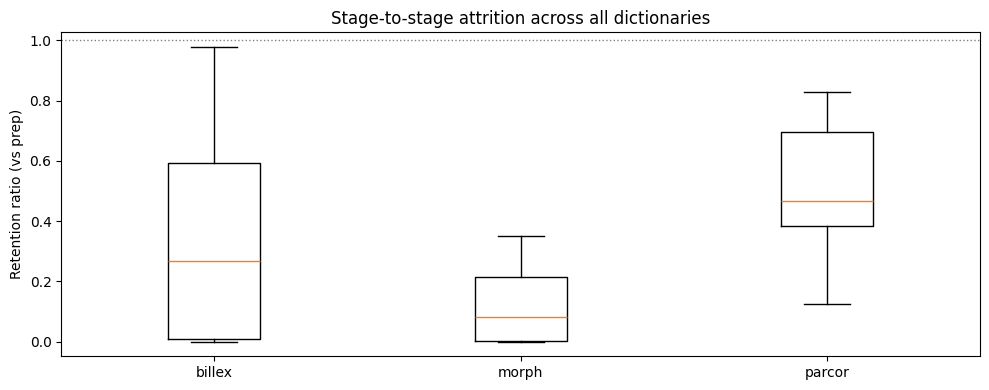

In [19]:
stage_cols = ["prep_rows", "billex_rows", "morph_rows", "parcor_rows"]
available = [c for c in stage_cols if c in metrics_df.columns]

if len(available) >= 2:
    stages_df = metrics_df[["dict_id"] + available].copy()

    # Compute attrition ratios relative to prep
    if "prep_rows" in stages_df.columns:
        for c in available:
            if c != "prep_rows":
                stages_df[c.replace("_rows", "_retention")] = (
                    stages_df[c] / stages_df["prep_rows"].replace(0, np.nan)
                ).round(3)

    print("=== Stage-to-stage row counts (sample of 10 dicts) ===")
    print(stages_df.head(10).to_string(index=False))

    stages_df.to_csv(DST_DIR / "_stage_attrition.csv", index=False)

    # Plot retention distribution
    retention_cols = [c for c in stages_df.columns if c.endswith("_retention")]
    if retention_cols:
        fig, ax = plt.subplots(figsize=(10, 4))
        data = [stages_df[c].dropna().values for c in retention_cols]
        ax.boxplot(data, labels=[c.replace("_retention", "") for c in retention_cols])
        ax.set_ylabel("Retention ratio (vs prep)")
        ax.set_title("Stage-to-stage attrition across all dictionaries")
        ax.axhline(1.0, color="grey", linestyle=":", linewidth=1)
        plt.tight_layout()
        plt.savefig(DST_DIR / "attrition_boxplot.png", dpi=120, bbox_inches="tight")
        plt.show()
else:
    print("Not enough stages available for attrition analysis.")

## 9. Before/after fix comparison

For dictionaries that have `_Fixed` versions, show what the fixes changed.

In [20]:
# Morphology: tag coverage before vs after
if "morph_tag_coverage" in metrics_df.columns and "morph_fixed_tag_coverage" in metrics_df.columns:
    comp = metrics_df[["dict_id", "morph_tag_coverage", "morph_fixed_tag_coverage"]].dropna()
    if len(comp) > 0:
        print("=== Morphology: tag coverage before vs after batch fix ===")
        print(f"Mean coverage BEFORE:  {comp['morph_tag_coverage'].mean():.1%}")
        print(f"Mean coverage AFTER:   {comp['morph_fixed_tag_coverage'].mean():.1%}")
        print(f"Dicts with >10% gain:  {(comp['morph_fixed_tag_coverage'] - comp['morph_tag_coverage'] > 0.1).sum()}")
        print()

# Parcor: placeholder rate before vs after
if "parcor_placeholder_rate" in metrics_df.columns and "parcor_fixed_placeholder_rate" in metrics_df.columns:
    comp = metrics_df[["dict_id", "parcor_placeholder_rate", "parcor_fixed_placeholder_rate"]].dropna()
    if len(comp) > 0:
        print("=== Parcor: unresolved placeholder rate before vs after batch fix ===")
        print(f"Mean rate BEFORE:  {comp['parcor_placeholder_rate'].mean():.1%}")
        print(f"Mean rate AFTER:   {comp['parcor_fixed_placeholder_rate'].mean():.1%}")
        print(f"Dicts with >20% reduction: {(comp['parcor_placeholder_rate'] - comp['parcor_fixed_placeholder_rate'] > 0.2).sum()}")

=== Morphology: tag coverage before vs after batch fix ===
Mean coverage BEFORE:  39.5%
Mean coverage AFTER:   60.8%
Dicts with >10% gain:  39

=== Parcor: unresolved placeholder rate before vs after batch fix ===
Mean rate BEFORE:  36.0%
Mean rate AFTER:   1.0%
Dicts with >20% reduction: 54


## 10. Pipeline-wide aggregate

Final numbers suitable for the thesis abstract / introduction.

In [21]:
aggregate = {
    "total_dictionaries_audited": len(metrics_df),
    "total_billex_entries": int(metrics_df.get("billex_rows", pd.Series()).sum()),
    "total_morphology_entries": int(metrics_df.get("morph_rows", pd.Series()).sum()),
    "total_parcor_pairs": int(metrics_df.get("parcor_rows", pd.Series()).sum()),
    # Pre-fix tier counts
    "tier_prefix_good": int((metrics_df["tier_prefix"] == "good").sum()),
    "tier_prefix_needs_attention": int((metrics_df["tier_prefix"] == "needs_attention").sum()),
    "tier_prefix_broken": int((metrics_df["tier_prefix"] == "broken").sum()),
    # Post-fix tier counts
    "tier_postfix_good": int((metrics_df["tier_postfix"] == "good").sum()),
    "tier_postfix_needs_attention": int((metrics_df["tier_postfix"] == "needs_attention").sum()),
    "tier_postfix_broken": int((metrics_df["tier_postfix"] == "broken").sum()),
    # Tier movement summary
    "tier_improved": int((
        metrics_df["violation_count_postfix"] < metrics_df["violation_count_prefix"]
    ).sum()),
    # Quality metric averages (using pre-fix values since fixed-only metrics may not exist for all dicts)
    "mean_billex_identical_rate": round(float(metrics_df.get("billex_identical_rate", pd.Series()).mean() or 0), 3),
    "mean_morph_tag_coverage_prefix": round(float(metrics_df.get("morph_tag_coverage", pd.Series()).mean() or 0), 3),
    "mean_morph_tag_coverage_postfix": round(float(metrics_df.get("morph_fixed_tag_coverage", pd.Series()).mean() or 0), 3),
    "mean_parcor_placeholder_rate_prefix": round(float(metrics_df.get("parcor_placeholder_rate", pd.Series()).mean() or 0), 3),
    "mean_parcor_placeholder_rate_postfix": round(float(metrics_df.get("parcor_fixed_placeholder_rate", pd.Series()).mean() or 0), 3),
}

agg_df = pd.DataFrame([aggregate]).T.rename(columns={0: "value"})
agg_df.to_csv(DST_DIR / "_aggregate_stats.csv")

for k, v in aggregate.items():
    if isinstance(v, float):
        print(f"  {k:<45} {v}")
    else:
        print(f"  {k:<45} {v:>8,}")

print(f"\nAll outputs written to: {DST_DIR.resolve()}")

  total_dictionaries_audited                          68
  total_billex_entries                           107,732
  total_morphology_entries                        40,245
  total_parcor_pairs                             116,398
  tier_prefix_good                                     2
  tier_prefix_needs_attention                         18
  tier_prefix_broken                                  48
  tier_postfix_good                                    4
  tier_postfix_needs_attention                        31
  tier_postfix_broken                                 33
  tier_improved                                       55
  mean_billex_identical_rate                    0.032
  mean_morph_tag_coverage_prefix                0.395
  mean_morph_tag_coverage_postfix               0.608
  mean_parcor_placeholder_rate_prefix           0.36
  mean_parcor_placeholder_rate_postfix          0.01

All outputs written to: C:\Users\Legion\OneDrive\Documents\UNI\TA\tugas-akhir-data-mining\TAEkstraksiKam

## 11. Drill-down (optional)

Inspect one dictionary in detail. Change `DRILL_DOWN_DICT_ID` to any ID
in your corpus (e.g. `"4"` for Jambi A-K).

In [22]:
DRILL_DOWN_DICT_ID = "4"

target = metrics_df[metrics_df["dict_id"] == DRILL_DOWN_DICT_ID]
if len(target) == 0:
    print(f"Dictionary {DRILL_DOWN_DICT_ID} not found in audit.")
else:
    row = target.iloc[0]
    print(f"=== Drill-down: dict {DRILL_DOWN_DICT_ID} ===")
    print(f"Tier (pre-fix):  {row['tier_prefix']}")
    print(f"Tier (post-fix): {row['tier_postfix']}")
    print(f"Violations (pre-fix):  {row['violations_prefix'] if row['violations_prefix'] else '(none)'}")
    print(f"Violations (post-fix): {row['violations_postfix'] if row['violations_postfix'] else '(none)'}")
    print()
    # Group metrics by resource. Show original metrics and their _fixed counterparts side-by-side.
    groups = ["prep_", "billex_", "morph_", "parcor_"]
    for g in groups:
        # original (non-fixed) cols
        cols = [c for c in row.index if c.startswith(g) and "fixed" not in c]
        if cols:
            print(f"--- {g.rstrip('_').upper()} ---")
            for c in cols:
                val = row[c]
                fixed_col = c.replace(g, f"{g}fixed_")
                fixed_val = row.get(fixed_col, None)
                if pd.notna(val):
                    if fixed_val is not None and pd.notna(fixed_val):
                        print(f"  {c:<40} {val}  (post-fix: {fixed_val})")
                    else:
                        print(f"  {c:<40} {val}")
            print()

=== Drill-down: dict 4 ===
Tier (pre-fix):  needs_attention
Tier (post-fix): needs_attention
Violations (pre-fix):  billex_high_multiword_ind;parcor_high_placeholders
Violations (post-fix): billex_high_multiword_ind

--- PREP ---
  prep_rows                                3213
  prep_anomali_rate                        0.277

--- BILLEX ---
  billex_rows                              1894
  billex_null_rate                         0.0
  billex_empty_ind_rate                    0.0
  billex_empty_reg_rate                    0.0
  billex_multiword_ind_rate                0.1193
  billex_multiword_reg_rate                0.0264
  billex_identical_rate                    0.2851
  billex_duplicate_rate                    0.0005
  billex_vocab_size_ind                    2155.0
  billex_vocab_size_reg                    1810.0
  billex_total_tokens_ind                  2233.0
  billex_total_tokens_reg                  1983.0
  billex_ttr_ind                           0.9651
  billex_ttr_reg  